
Final Q-table:
[[0.715 0.892 0.697 0.732]
 [0.695 0.    0.336 0.545]
 [0.568 0.014 0.002 0.124]
 [0.049 0.    0.002 0.001]
 [0.708 0.884 0.    0.755]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.073]
 [0.    0.    0.    0.   ]
 [0.734 0.    0.876 0.766]
 [0.807 0.898 0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.887 0.967 0.791]
 [0.952 0.99  1.    0.   ]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.892 0.695 0.568 0.049]
 [0.884 0.    0.073 0.   ]
 [0.876 0.898 0.    0.   ]
 [0.    0.967 1.    0.   ]]

Learned Policy:
[['D' 'L' 'L' 'L']
 ['D' 'L' 'U' 'L']
 ['R' 'D' 'L' 'L']
 ['L' 'R' 'R' 'L']]

Average reward over last 1000 episodes: 0.909

Final Epsilon: 0.05


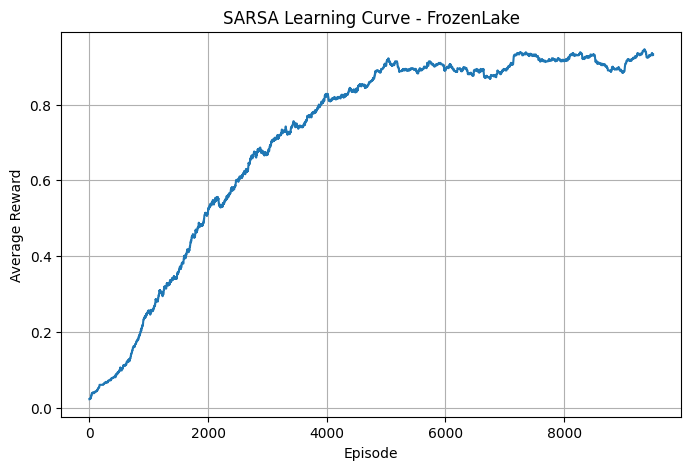

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


custom_map = [
    "SFFF",
    "FHFH",
    "FFHF",
    "HFFG"
]

env = gym.make(
    "FrozenLake-v1",
    desc=custom_map,
    is_slippery=False
)


# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

num_episodes = 10000
max_steps_per_episode = 100

alpha = 0.1          # Learning rate
gamma = 0.99         # Discount factor

epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.05
epsilon_decay = 0.9995


# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

n_states = env.observation_space.n
n_actions = env.action_space.n

Q = np.zeros((n_states, n_actions))

episode_rewards = []

# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def epsilon_greedy_action(state, epsilon):

    # Explore
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploit
    max_q = np.max(Q[state])

    # Randomly select among equally good actions
    best_actions = np.flatnonzero(Q[state] == max_q)

    return np.random.choice(best_actions)



for episode in range(num_episodes):

    # Reset environment
    state, info = env.reset()

    # Select initial action
    action = epsilon_greedy_action(state, epsilon)

    total_reward = 0

    for step in range(max_steps_per_episode):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Select next action using current epsilon
        next_action = epsilon_greedy_action(next_state, epsilon)

        # SARSA update
        if terminated or truncated:

            target = reward

        else:

            target = (
                reward
                + gamma * Q[next_state, next_action]
            )

        Q[state, action] += alpha * (
            target - Q[state, action]
        )

        # Move to next state
        state = next_state
        action = next_action

        total_reward += reward

        # Stop episode
        if terminated or truncated:
            break

    # Store reward
    episode_rewards.append(total_reward)

    # Variable epsilon decay
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )



def print_value_function(values):

    print("\nEstimated State-Value Function:")

    print(
        np.round(
            values.reshape(4, 4),
            3
        )
    )


def print_policy(policy):

    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [
            action_symbols[action]
            for action in policy
        ]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


state_values = np.max(Q, axis=1)

learned_policy = np.argmax(Q, axis=1)


print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)

print_policy(learned_policy)

average_reward = np.mean(
    episode_rewards[-1000:]
)

print(
    "\nAverage reward over last 1000 episodes:",
    average_reward
)

print(
    "\nFinal Epsilon:",
    epsilon
)


window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))

plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("SARSA Learning Curve - FrozenLake")

plt.grid(True)

plt.show()

env.close()
